# 05 NMDA Scaling

## What this notebook is about

This notebook tests a proposed fix for one specific failure of our dendrite
sequence detector, finds that the proposed fix does not work, and then shows
which knob actually does. Reporting both halves honestly is the point: knowing
why a plausible idea fails tells us where the real problem lives.

We model a neuron's **dendrite** as 12 small compartments ("segments") in a line. Each
segment carries a regenerative **NMDA** channel (once a segment depolarizes, NMDA
pushes it further up and holds it in an "up" plateau) balanced against a restoring
**KIR** channel (which pulls it back down). On top of that intrinsic machinery,
incoming spikes deliver two kinds of synaptic drive: fast **AMPA** and slower
**synaptic NMDA**. We feed the dendrite a target **sequence**, namely bursts
arriving at segments 5, then 6, then 7, then 8, and ask it to light those segments
up in that order.

### The failure we are trying to fix

Notebook 3 mapped where this detector behaves well. It found one robust failure:
when the input bursts **overlap heavily in time** (wake-like, about 3.5 ms of
overlap), the detector becomes **too permissive** and accepts even a fully
reversed sequence (8, 7, 6, 5). The bursts arrive so nearly together that every
segment gets dragged into the "up" state regardless of order, producing a **false
plateau**, and the order information is lost.

### The hypothesis this notebook tests

Our project proposal offers **uniform NMDA conductance scaling** as a candidate
fix, with this reasoning: reduce the peak NMDA conductance so that each individual
spike contributes less depolarization to a segment, so that if no single spike,
nor a small accumulation of spikes, can push a segment to plateau on its own,
then burst-driven false plateaus become less likely. Concretely, turning the
synaptic NMDA scale **down** should make the detector harder to flood, and so
should shrink the too-permissive failure at heavy overlap. That is the
prediction, and the rest of the notebook is built to confirm or refute it rather
than to assume it.

### What we are going to do, and why

1. **Set up the model and scoring (Section 1).** The same order-based accept and
   reject machinery as notebook 3, so the results are directly comparable.
2. **Look at one operating point up close (Section 2).** Confirm the detector
   cleanly separates forward, swap, and reversed inputs at the default settings,
   establishing the baseline the fix is supposed to improve on.
3. **Test the proposed NMDA-scaling fix (Section 3).** Sweep the synaptic NMDA
   scale against burst overlap and color each combination by behavior. If the
   hypothesis is right, the too-permissive region should retreat as the knob
   scales down.
4. **Test AMPA scaling instead (Section 4).** Having found the NMDA knob inert,
   we ask whether scaling the other synaptic drive, AMPA, changes anything, and
   sweep it the same way.
5. **Diagnose the mechanism (Section 5).** Decompose the synaptic current at the
   failure to show which drive actually carries the depolarization, which is what
   earns the conclusion rather than asserting it.

## Section 1: Model setup and scoring tools

Before any experiment we fix the settings that define the dendrite and its
inputs, and a consistent rule for deciding whether a run counts as a detection.
We deliberately reuse notebook 3's scoring so the two notebooks can be read side
by side.

- We watch segments **[5, 6, 7, 8]**, the target sequence, fixed everywhere.
- The intrinsic bistability is pinned at the **validated swap-tolerant center**
  from notebook 3: `G_NMDA = G_KIR = 20` (ratio 1.0). We are not changing the
  intrinsic NMDA/KIR balance here, since notebook 3 already studied that. This
  notebook changes a different knob.
- The knob we vary first is **`G_NMDA_syn`**, the gain on the spike-driven
  (synaptic) NMDA conductance. This is the peak NMDA conductance the proposal
  proposes to scale: `G_NMDA_syn = 1.0` is the default, values below 1 implement
  the proposed reduction, and values above 1 let us see the opposite extreme.
- The three input patterns (forward, adjacent-swap, and reversed) are defined
  here once.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import make_burst_sequence, g_AMPA_vector, g_NMDA_vector
from src.dendrite import simulate_dendrite, score_detection
from src.channels import sigma_NMDA, E_NMDA, E_AMPA

# Fixed parameters (inherited from notebooks 00, 01 and 03)
n_segments        = 12
sequence_segments = [5, 6, 7, 8]
T                 = 90.0
dt                = 0.02
G_ax              = 1.0
start_time        = 10.0
weight            = 1.0

# Intrinsic bistability is PINNED at notebook 3's validated swap-tolerant center
# (ratio 1.0). We are not changing the intrinsic NMDA/KIR balance in this
# notebook, only the spike-driven synaptic drives below.
G_NMDA_intrinsic  = 20.0
G_KIR             = 20.0

# Default synaptic gains. G_NMDA_syn is the knob the proposal proposes to scale;
# G_AMPA is the fast excitatory drive we test in Section 4.
G_NMDA_syn_default = 1.0
G_AMPA_default     = 1.0

# Burst parameters matching notebook 01
burst_len  = 3
isi_ms     = 2.0
burst_span = (burst_len - 1) * isi_ms   # 4.0 ms

# Three sequence types tested throughout
SEQ_FORWARD  = [5, 6, 7, 8]   # target sequence
SEQ_ADJ_SWAP = [6, 5, 7, 8]   # one adjacent swap
SEQ_REVERSED = [8, 7, 6, 5]   # fully reversed

### Turning a simulation into a yes or no decision

A raw simulation only gives us voltage traces. To compare hundreds of runs we
reduce each to a single decision: did the dendrite accept this input as the target
sequence? The cell below defines that machinery, identical in spirit to notebook
3, plus `run_sequence`, which launches one simulation at a chosen synaptic NMDA
gain and AMPA gain.

The key design choice is the same as before. We score by **activation order**,
not by whether every segment lit up. When bursts overlap, every segment
eventually gets dragged high even for reversed input, so an "all segments fired"
rule would pass everything. Instead we record when each target segment first
crosses threshold and count how many neighboring pairs fired out of order
relative to the fixed target [5, 6, 7, 8]:

    forward  [5,6,7,8] -> 0 pairs out of order   -> clean,  accept
    adj swap [6,5,7,8] -> 1 pair  out of order    -> jitter, accept
    reversed [8,7,6,5] -> 2 or more out of order  -> wrong,  reject

A run is **accepted** when every target segment fired, the last one stayed high
at the end, and the out-of-order count is within budget (0 for forward, 1 for
swap and reversed). `classify_point` then bundles the three results into one of
four labels: failure, too strict, swap-tolerant, or too permissive. Those four
labels are the colors of the phase diagrams later. The only thing `run_sequence`
changes between runs is the two synaptic gains; the intrinsic ratio stays fixed.

In [2]:
def overlap_to_onset(overlap_ms):
    """Convert overlap duration to onset_step_ms (smaller onset = more overlap)."""
    return max(0.01, burst_span - overlap_ms)


def run_sequence(seq, onset_step, g_nmda_syn=G_NMDA_syn_default, g_ampa=G_AMPA_default):
    """Run one sequence type at chosen synaptic gains.

    The intrinsic bistability is held fixed at the swap-tolerant center
    (``G_NMDA = G_KIR = 20``). The only things that change between runs are
    ``g_nmda_syn`` (the synaptic NMDA gain, the knob the proposal proposes to
    scale) and ``g_ampa`` (the fast excitatory drive tested in Section 4).
    """
    events, _ = make_burst_sequence(
        sequence_segments=seq,
        start_time=start_time,
        onset_step_ms=onset_step,
        burst_len=burst_len,
        isi_ms=isi_ms,
        weight=weight,
    )
    times, V_hist = simulate_dendrite(
        n_segments=n_segments,
        T=T,
        dt=dt,
        G_NMDA=G_NMDA_intrinsic,   # intrinsic, fixed
        G_KIR=G_KIR,               # intrinsic, fixed
        G_ax=G_ax,
        G_AMPA=g_ampa,             # fast excitatory drive
        G_NMDA_syn=g_nmda_syn,     # spike-driven NMDA gain
        ampa_events=events,
    )
    return times, V_hist


def count_order_violations(activation_times):
    """Number of adjacent TARGET pairs that activate out of order.

    The target order is always ``sequence_segments`` = [5, 6, 7, 8]. A violation
    is a later target segment crossing threshold before the one that should
    precede it. Measured against the fixed target, never against the (possibly
    swapped or reversed) input order.
    """
    t = [activation_times[int(s)] for s in sequence_segments]
    v = 0
    for a, b in zip(t[:-1], t[1:]):
        if np.isfinite(a) and np.isfinite(b) and b < a:
            v += 1
    return v


def accept_sequence(score, max_violations):
    """Did the detector accept this input as a forward-ish sequence?

    Acceptance requires every target segment to cross threshold, the final target
    segment to stay high, AND the activation order to have at most
    ``max_violations`` swaps. This scores order, not merely whether every segment
    lit up.
    """
    if not score["all_detected"]:
        return False
    if not score["final_high"]:
        return False
    return count_order_violations(score["activation_times"]) <= max_violations


def classify_point(fwd_pass, adj_pass, rev_pass):
    """Map pass and fail flags to a regime integer.

    0 = failure        fwd fails, cannot detect the original sequence
    1 = too strict     adj fails, rejects even one swap
    2 = swap-tolerant  fwd and adj pass, rev fails (the target regime)
    3 = too permissive rev passes, no selectivity left
    """
    if not fwd_pass:
        return 0
    if rev_pass:
        return 3
    if adj_pass:
        return 2
    return 1


# Shared phase-diagram styling, used by both sweeps below.
REGIME_COLORS = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e"]
REGIME_LABELS = [
    "Failure  (fwd not detected)",
    "Too strict  (rejects the swap)",
    "Swap-tolerant  (accepts swap, rejects reversal)",
    "Too permissive  (accepts reversal)",
]
REGIME_CMAP = plt.matplotlib.colors.ListedColormap(REGIME_COLORS)


def make_edges(centers):
    """Bin edges for pcolormesh from cell centers."""
    c = np.asarray(centers, dtype=float)
    edges = np.empty(len(c) + 1)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0]    = c[0]  - (c[1]  - c[0])  / 2
    edges[-1]   = c[-1] + (c[-1] - c[-2]) / 2
    return edges


def sweep_grid(yvals, overlaps, knob):
    """Run the full sweep for one knob and return the regime grid.

    ``knob`` is either "nmda_syn" or "ampa". For each (yval, overlap) we run all
    three sequence types and classify the outcome.
    """
    grid = np.zeros((len(yvals), len(overlaps)), dtype=int)
    for i, yv in enumerate(yvals):
        for j, overlap in enumerate(overlaps):
            onset_step = overlap_to_onset(overlap)
            if knob == "nmda_syn":
                kw = dict(g_nmda_syn=yv)
            else:
                kw = dict(g_ampa=yv)
            s_fwd = score_detection(*run_sequence(SEQ_FORWARD,  onset_step, **kw), sequence_segments)
            s_adj = score_detection(*run_sequence(SEQ_ADJ_SWAP, onset_step, **kw), sequence_segments)
            s_rev = score_detection(*run_sequence(SEQ_REVERSED, onset_step, **kw), sequence_segments)
            fwd_pass = accept_sequence(s_fwd, max_violations=0)
            adj_pass = accept_sequence(s_adj, max_violations=1)
            rev_pass = accept_sequence(s_rev, max_violations=1)
            grid[i, j] = classify_point(fwd_pass, adj_pass, rev_pass)
        print(f"  {knob} = {yv:.2f}  done")
    return grid


def plot_phase(grid, yvals, overlaps, ylabel, title, star=None):
    """Draw a regime phase diagram with the shared 4-color scheme."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.pcolormesh(make_edges(overlaps), make_edges(yvals), grid,
                  cmap=REGIME_CMAP, vmin=-0.5, vmax=3.5)
    ax.set_xlabel("burst overlap duration (ms)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(overlaps)
    patches = [mpatches.Patch(color=REGIME_COLORS[k], label=REGIME_LABELS[k]) for k in range(4)]
    ax.legend(handles=patches, loc="center left", bbox_to_anchor=(1.02, 0.5),
              fontsize=9, framealpha=0.95)
    if star is not None:
        ax.scatter([star[0]], [star[1]], marker="*", s=300, color="white",
                   edgecolor="black", linewidth=0.8, zorder=5)
    plt.tight_layout()
    plt.show()
    return ax

## Section 2: One operating point, up close

Before sweeping anything, we confirm the detector works at the default settings.
This is the baseline the fix is meant to improve. We run the three input types at
the default synaptic gains (`G_NMDA_syn = 1.0`, `G_AMPA = 1.0`) and a mild burst
overlap of 1 ms, which sits well inside the swap-tolerant zone, and watch them on
the actual voltage traces.

**The cell below** runs forward, single-swap, and reversed inputs, plots each
segment's voltage over time, and prints the activation times and accept or reject
decision for each. We expect a clean separation: forward and the single swap
accepted, the reversal rejected.

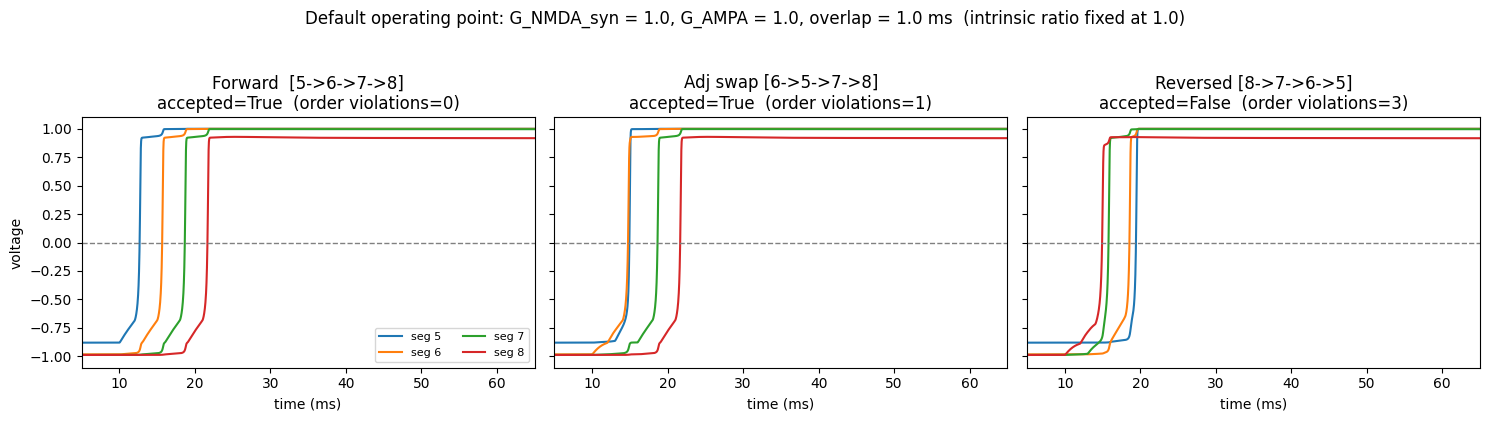

Scores  (G_NMDA_syn=1.0, G_AMPA=1.0, overlap=1.0 ms)
--------------------------------------------------------------------------------------------
Forward  [5->6->7->8]     accepted=True   order_violations=0  all_detected=True   final_high=True   activation[5,6,7,8]=[12.7-15.7-18.7-21.7]
Adj swap [6->5->7->8]     accepted=True   order_violations=1  all_detected=True   final_high=True   activation[5,6,7,8]=[14.9-14.8-18.7-21.7]
Reversed [8->7->6->5]     accepted=False  order_violations=3  all_detected=True   final_high=True   activation[5,6,7,8]=[19.4-18.6-15.8-14.9]


In [3]:
# Demonstrate the detector at the DEFAULT operating point:
#   G_NMDA_syn = 1.0, G_AMPA = 1.0, mild burst overlap of 1 ms,
#   intrinsic ratio fixed at the swap-tolerant center (G_NMDA = G_KIR = 20).
# This is the baseline both proposed knobs are tested against.

gsyn_demo       = G_NMDA_syn_default          # 1.0 (default synaptic NMDA gain)
overlap_demo    = 1.0                         # ms (mild overlap, well below flooding)
onset_step_demo = overlap_to_onset(overlap_demo)

seq_defs = [
    ("Forward  [5->6->7->8]", SEQ_FORWARD,  0),  # require perfect order
    ("Adj swap [6->5->7->8]", SEQ_ADJ_SWAP, 1),  # tolerate one swap
    ("Reversed [8->7->6->5]", SEQ_REVERSED, 1),  # judged by the same accept test
]

results_base = []
for label, seq, max_v in seq_defs:
    times, V_hist = run_sequence(seq, onset_step_demo, g_nmda_syn=gsyn_demo)
    s = score_detection(times, V_hist, sequence_segments)
    accepted = accept_sequence(s, max_violations=max_v)
    nviol = count_order_violations(s["activation_times"])
    results_base.append((label, times, V_hist, s, accepted, nviol))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (label, times, V_hist, s, accepted, nviol) in zip(axes, results_base):
    for seg in sequence_segments:
        ax.plot(times, V_hist[:, seg], label=f"seg {seg}")
    ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_xlim(5, 65)
    ax.set_xlabel("time (ms)")
    ax.set_title(f"{label}\naccepted={accepted}  (order violations={nviol})")
axes[0].set_ylabel("voltage")
axes[0].legend(ncol=2, fontsize=8)
plt.suptitle(
    f"Default operating point: "
    f"G_NMDA_syn = {gsyn_demo:.1f}, G_AMPA = {G_AMPA_default:.1f}, "
    f"overlap = {overlap_demo} ms  (intrinsic ratio fixed at 1.0)",
    y=1.04,
)
plt.tight_layout()
plt.show()

print(f"Scores  (G_NMDA_syn={gsyn_demo:.1f}, G_AMPA={G_AMPA_default:.1f}, overlap={overlap_demo} ms)")
print("-" * 92)
for label, times, V_hist, s, accepted, nviol in results_base:
    order = "-".join(
        f"{s['activation_times'][int(seg)]:.1f}"
        if np.isfinite(s['activation_times'][int(seg)]) else "X"
        for seg in sequence_segments
    )
    print(
        f"{label:24s}  accepted={str(accepted):5}  "
        f"order_violations={nviol}  all_detected={str(s['all_detected']):5}  "
        f"final_high={str(s['final_high']):5}  activation[5,6,7,8]=[{order}]"
    )

##### Key:

- **accepted** = `True/False`: did the detector accept this input as the target
  forward sequence (every target segment fired, the last stayed high, and the
  activation order was within the allowed swap budget)?
- **order_violations** = integer: how many adjacent target pairs fired out of
  order relative to [5, 6, 7, 8] (forward = 0, single swap = 1, reversal 2 or
  more).
- **all_detected** = `True/False`: did every target segment cross threshold at
  all?
- **final_high** = `True/False`: did the last target segment stay in the "up"
  plateau through the end of the run?
- **activation[5,6,7,8]** = `[...]`: the time in ms each target segment first
  crossed threshold (`X` means it never fired).

### A closer look at the burst: the NMDA residual that adds up

The operating point above works because each segment is driven by a three-spike burst, not a single spike, and the three spikes land only 2 ms apart. That spacing is the whole point. NMDA decays slowly (the paper's decay constants are 12.6, 57.3, and 372 ms), so the conductance opened by the first spike has barely faded when the second and third arrive, and the contributions sum. AMPA decays with a 3 ms time constant.

At a 2 ms spacing both channels actually sum a little while the burst is still firing, so summation by itself is not the distinction. The difference shows up in how long the summed conductance lasts after the burst ends. NMDA holds its accumulated conductance for tens of milliseconds, across the plateau window that latches the segment, while AMPA collapses back toward zero within about 10 ms.

The cell below takes the exact spike times the baseline used for the first segment of the forward sequence (segment 5, firing at 10, 12, and 14 ms) and evaluates the synaptic conductance kernels those spikes produce. It compares a single spike against all three summed, and reports how much conductance remains at several times after the last spike. This residual summation is what every `simulate_dendrite` call in this notebook relies on, realized in code by `g_NMDA_vector` summing the kernels of all spike events.

Baseline burst spike times for segment 5: [10.0, 12.0, 14.0] ms  (ISI = 2.0 ms)

Residual from earlier spikes, at the instant each new burst spike fires:
  spike 1 @   10 ms   leftover NMDA = 0.000   leftover AMPA = 0.000
  spike 2 @   12 ms   leftover NMDA = 0.824   leftover AMPA = 0.930
  spike 3 @   14 ms   leftover NMDA = 1.812   leftover AMPA = 1.886

Summed conductance remaining after the last spike (t = 14 ms):
  t =   14 ms (+ 0)   NMDA = 1.812   AMPA = 1.886
  t =   19 ms (+ 5)   NMDA = 2.939   AMPA = 1.877
  t =   24 ms (+10)   NMDA = 2.729   AMPA = 0.642
  t =   34 ms (+20)   NMDA = 2.367   AMPA = 0.043
  t =   54 ms (+40)   NMDA = 1.925   AMPA = 0.000


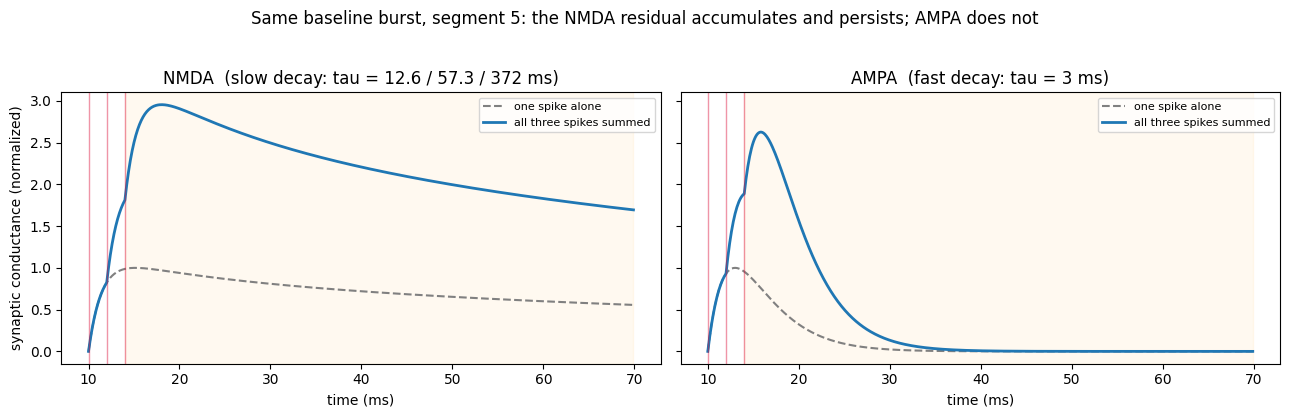


Peak summed NMDA = 2.954 vs single-spike 1.000 (2.95x).  20 ms after the burst, NMDA is still 2.367 while AMPA has fallen to 0.043.


In [4]:
# Anchor to the SAME baseline burst used in Section 2 (forward sequence,
# overlap = 1 ms). We do NOT re-simulate; we evaluate the synaptic conductance
# kernels directly, using the exact spike times the baseline injected into the
# first segment (segment 5). This isolates the residual-summation effect that
# the full simulation relies on.
from src.inputs import nmda_conductance, alpha_conductance

# Reconstruct the baseline burst timing for segment 5.
onset_step_base = overlap_to_onset(1.0)            # overlap = 1 ms, as in Section 2
_, raster_base = make_burst_sequence(
    sequence_segments=SEQ_FORWARD, start_time=start_time,
    onset_step_ms=onset_step_base, burst_len=burst_len,
    isi_ms=isi_ms, weight=weight,
)
seg5_spikes = raster_base[5]
print(f"Baseline burst spike times for segment 5: {seg5_spikes} ms  (ISI = {isi_ms} ms)\n")

def running_sum(kernel, spikes, t):
    """Conductance at time t from every spike that has already fired by t."""
    return sum(kernel(t, s) for s in spikes if s <= t)

# (1) Residual still present from earlier spikes AT the instant each new spike fires.
print("Residual from earlier spikes, at the instant each new burst spike fires:")
for i, st in enumerate(seg5_spikes):
    rn = running_sum(nmda_conductance, seg5_spikes[:i], st)
    ra = running_sum(alpha_conductance, seg5_spikes[:i], st)
    print(f"  spike {i+1} @ {st:4.0f} ms   leftover NMDA = {rn:5.3f}   leftover AMPA = {ra:5.3f}")

# (2) The real contrast: how long the SUMMED conductance lasts after the burst ends.
last = seg5_spikes[-1]
print(f"\nSummed conductance remaining after the last spike (t = {last:.0f} ms):")
for d in [0, 5, 10, 20, 40]:
    t = last + d
    print(f"  t = {t:4.0f} ms (+{d:2d})   NMDA = {running_sum(nmda_conductance, seg5_spikes, t):5.3f}"
          f"   AMPA = {running_sum(alpha_conductance, seg5_spikes, t):5.3f}")

# (3) Plot single-spike vs all-three-summed for each channel.
tgrid  = np.arange(seg5_spikes[0], seg5_spikes[0] + 60.0, 0.1)
gN_sum = np.array([running_sum(nmda_conductance, seg5_spikes, t) for t in tgrid])
gA_sum = np.array([running_sum(alpha_conductance, seg5_spikes, t) for t in tgrid])
gN_one = np.array([nmda_conductance(t, seg5_spikes[0]) for t in tgrid])
gA_one = np.array([alpha_conductance(t, seg5_spikes[0]) for t in tgrid])

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
panels = [
    (axes[0], "NMDA  (slow decay: tau = 12.6 / 57.3 / 372 ms)", gN_one, gN_sum),
    (axes[1], "AMPA  (fast decay: tau = 3 ms)",                 gA_one, gA_sum),
]
for ax, title, one, summ in panels:
    ax.plot(tgrid, one,  "--", color="gray", label="one spike alone")
    ax.plot(tgrid, summ, "-",  color="C0", lw=2, label="all three spikes summed")
    for st in seg5_spikes:
        ax.axvline(st, color="crimson", lw=1, alpha=0.45)
    ax.axvspan(last, tgrid[-1], color="orange", alpha=0.06)
    ax.set_title(title)
    ax.set_xlabel("time (ms)")
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("synaptic conductance (normalized)")
plt.suptitle("Same baseline burst, segment 5: the NMDA residual accumulates and persists; "
             "AMPA does not", y=1.03)
plt.tight_layout()
plt.show()

print(f"\nPeak summed NMDA = {gN_sum.max():.3f} vs single-spike {gN_one.max():.3f} "
      f"({gN_sum.max()/gN_one.max():.2f}x).  "
      f"20 ms after the burst, NMDA is still {running_sum(nmda_conductance, seg5_spikes, last + 20):.3f} "
      f"while AMPA has fallen to {running_sum(alpha_conductance, seg5_spikes, last + 20):.3f}.")


## Section 3: Does scaling synaptic NMDA help? The phase diagram

Here, we vary the synaptic NMDA gain
`G_NMDA_syn` (vertical axis) against burst overlap (horizontal axis), and at every
grid point run all three input types and color the cell by the resulting
behavior:

- **Failure** (red): cannot even follow the forward sequence.
- **Too strict** (blue): follows forward but rejects the harmless single swap.
- **Swap-tolerant** (green): the target. Accepts forward and the swap, rejects the
  reversal.
- **Too permissive** (orange): accepts everything, reversal included. This is the
  failure the fix is meant to remove.

If reducing peak NMDA really starves the false
plateau, then moving down the vertical axis (smaller `G_NMDA_syn`) should turn the
orange too-permissive cells at high overlap green. A working fix would show a
clear vertical gradient.

We sample the gain finely (0.1 steps from 0 to 2, where 1.0 is the default and 0
means no synaptic NMDA at all); the tick labels stay at 0.5 intervals for
readability. The intrinsic ratio is held fixed at 1.0 throughout, so the only
thing changing down each column is the knob we are testing. The white star marks
the Section-2 operating point (`G_NMDA_syn = 1.0`, overlap 1.0 ms).

Running NMDA-scaling sweep  (504 simulations) ...
  nmda_syn = 0.00  done
  nmda_syn = 0.10  done
  nmda_syn = 0.20  done
  nmda_syn = 0.30  done
  nmda_syn = 0.40  done
  nmda_syn = 0.50  done
  nmda_syn = 0.60  done
  nmda_syn = 0.70  done
  nmda_syn = 0.80  done
  nmda_syn = 0.90  done
  nmda_syn = 1.00  done
  nmda_syn = 1.10  done
  nmda_syn = 1.20  done
  nmda_syn = 1.30  done
  nmda_syn = 1.40  done
  nmda_syn = 1.50  done
  nmda_syn = 1.60  done
  nmda_syn = 1.70  done
  nmda_syn = 1.80  done
  nmda_syn = 1.90  done
  nmda_syn = 2.00  done
Sweep complete.


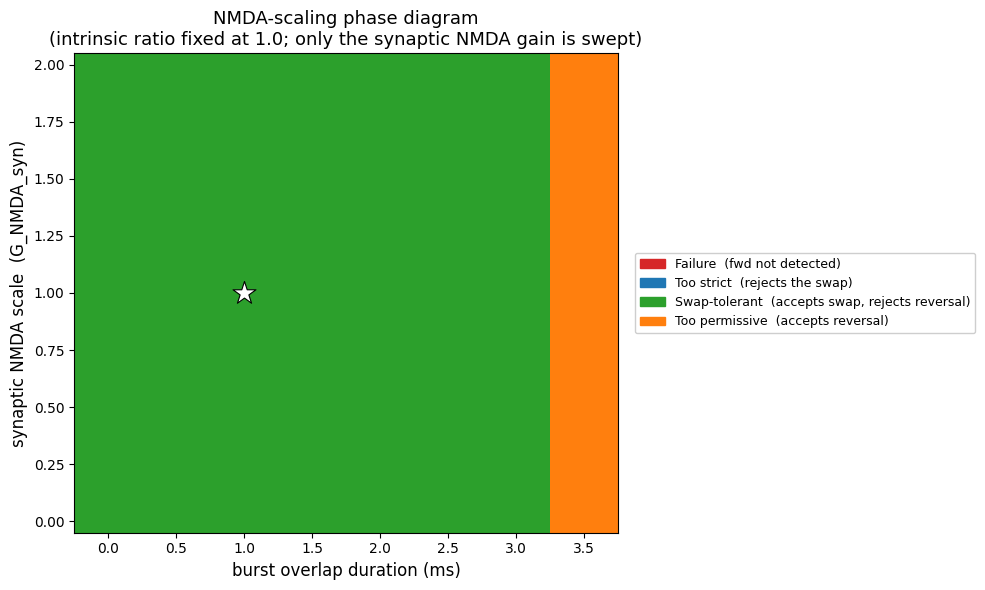

In [5]:
# Sweep the SYNAPTIC NMDA gain (G_NMDA_syn) against burst overlap, intrinsic
# ratio fixed at the swap-tolerant center. Fine 0.1 sampling of the gain from 0
# (no synaptic NMDA) to 2; tick labels stay at 0.5 intervals.

nmda_syn_scales = np.round(np.arange(0.0, 2.0001, 0.1), 2)   # 0.0 .. 2.0, fine
overlaps        = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])

print("Running NMDA-scaling sweep  ({} simulations) ...".format(
    len(nmda_syn_scales) * len(overlaps) * 3))
grid_nmda = sweep_grid(nmda_syn_scales, overlaps, knob="nmda_syn")
print("Sweep complete.")

ax = plot_phase(
    grid_nmda, nmda_syn_scales, overlaps,
    ylabel="synaptic NMDA scale  (G_NMDA_syn)",
    title="NMDA-scaling phase diagram\n(intrinsic ratio fixed at 1.0; only the synaptic NMDA gain is swept)",
    star=(overlap_demo, gsyn_demo),
)
ax.set_yticks(np.arange(0.0, 2.0001, 0.5))

### Reading the NMDA-scaling result off the grid

The cell below extracts the exact boundaries directly from `grid_nmda`, the
array of regime labels the sweep just produced.

In [6]:
# Read the exact extent of each regime straight from grid_nmda (no new sims).
# Grid axes: rows = synaptic NMDA scale, columns = burst overlap (ms).

REGIME_NAMES = [
    "Failure        (red)",
    "Too strict     (blue)",
    "Swap-tolerant  (green)",
    "Too permissive (orange)",
]


def contiguous_runs(vals):
    """Group a sorted list of scales into contiguous 0.1-spaced runs."""
    runs = []
    for v in vals:
        if runs and round(v - runs[-1][1], 2) <= 0.1 + 1e-9:
            runs[-1][1] = v
        else:
            runs.append([v, v])
    return runs


def fmt_runs(runs):
    return ", ".join(f"{a:.1f}" if a == b else f"{a:.1f}-{b:.1f}" for a, b in runs)


def report_extents(grid, yvals, overlaps, yname):
    print(f"Exact regime extents  ({yname})")
    print("=" * 66)
    for code, name in enumerate(REGIME_NAMES):
        mask = grid == code
        if not mask.any():
            print(f"\n{name}:  not present in this grid")
            continue
        sc = yvals[mask.any(axis=1)]
        ov = overlaps[mask.any(axis=0)]
        print(f"\n{name}")
        print(f"  scale range  : {sc.min():.2f} - {sc.max():.2f}")
        print(f"  overlap range: {ov.min():.1f} - {ov.max():.1f} ms")
        for j, o in enumerate(overlaps):
            col = sorted(yvals[grid[:, j] == code])
            if col:
                print(f"    overlap {o:>3.1f} ms : scale {fmt_runs(contiguous_runs(col))}")


report_extents(grid_nmda, nmda_syn_scales, overlaps,
               "rows = synaptic NMDA scale, intrinsic ratio fixed at 1.0")

Exact regime extents  (rows = synaptic NMDA scale, intrinsic ratio fixed at 1.0)

Failure        (red):  not present in this grid

Too strict     (blue):  not present in this grid

Swap-tolerant  (green)
  scale range  : 0.00 - 2.00
  overlap range: 0.0 - 3.0 ms
    overlap 0.0 ms : scale 0.0-2.0
    overlap 0.5 ms : scale 0.0-2.0
    overlap 1.0 ms : scale 0.0-2.0
    overlap 1.5 ms : scale 0.0-2.0
    overlap 2.0 ms : scale 0.0-2.0
    overlap 2.5 ms : scale 0.0-2.0
    overlap 3.0 ms : scale 0.0-2.0

Too permissive (orange)
  scale range  : 0.00 - 2.00
  overlap range: 3.5 - 3.5 ms
    overlap 3.5 ms : scale 0.0-2.0


## Section 4: Does scaling AMPA help instead?

Here, we run the identical sweep on `G_AMPA` to see whether it has any leverage the
NMDA knob lacked.

We sweep `G_AMPA` from 0.25 to 2.0 against the same overlap axis, with both the
intrinsic ratio and the synaptic NMDA gain held at their defaults, so the only
thing changing is the AMPA gain. 

Running AMPA-scaling sweep  (456 simulations) ...
  ampa = 0.25  done
  ampa = 0.35  done
  ampa = 0.45  done
  ampa = 0.55  done
  ampa = 0.65  done
  ampa = 0.75  done
  ampa = 0.85  done
  ampa = 0.95  done
  ampa = 1.05  done
  ampa = 1.15  done
  ampa = 1.25  done
  ampa = 1.35  done
  ampa = 1.45  done
  ampa = 1.55  done
  ampa = 1.65  done
  ampa = 1.75  done
  ampa = 1.85  done
  ampa = 1.95  done
  ampa = 2.00  done
Sweep complete.


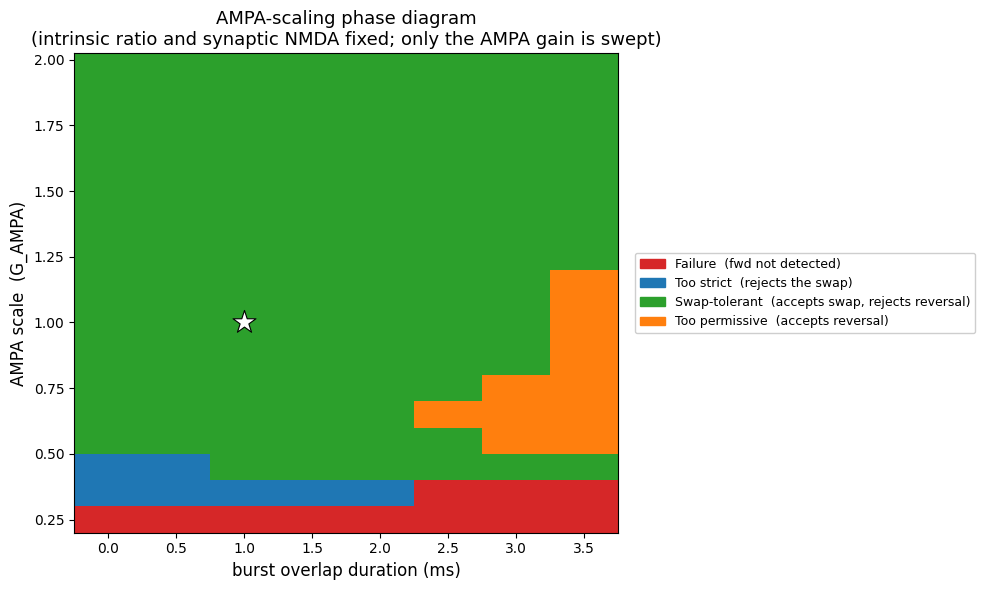

In [7]:
# Sweep the AMPA gain (G_AMPA) against burst overlap, with the intrinsic ratio
# and synaptic NMDA gain held at their defaults. Fine 0.1 sampling from 0.25 to 2.

ampa_scales = np.round(np.arange(0.25, 2.0001, 0.1), 2)   # 0.25 .. ~1.95 + 2.0
ampa_scales = np.append(ampa_scales, 2.0) if ampa_scales[-1] < 2.0 else ampa_scales
ampa_scales = np.unique(np.round(ampa_scales, 2))

print("Running AMPA-scaling sweep  ({} simulations) ...".format(
    len(ampa_scales) * len(overlaps) * 3))
grid_ampa = sweep_grid(ampa_scales, overlaps, knob="ampa")
print("Sweep complete.")

ax = plot_phase(
    grid_ampa, ampa_scales, overlaps,
    ylabel="AMPA scale  (G_AMPA)",
    title="AMPA-scaling phase diagram\n(intrinsic ratio and synaptic NMDA fixed; only the AMPA gain is swept)",
    star=(overlap_demo, G_AMPA_default),
)
ax.set_yticks(np.arange(0.25, 2.0001, 0.25))

### Zooming in on the failure column

Viewing the overlap-3.5 cell change regime as AMPA scales.

In [8]:
# Numerical detail at the worst-case overlap (3.5 ms): does raising G_AMPA restore
# rejection of the reversal? Print the accept decision and activation times.
OV_FAIL    = 3.5
onset_fail = overlap_to_onset(OV_FAIL)


def act_str(s):
    return "[" + ", ".join(
        f"{s['activation_times'][k]:.2f}" if np.isfinite(s['activation_times'][k]) else "X"
        for k in sequence_segments) + "]"


print("Overlap = 3.5 ms (worst case). Reversed input SHOULD be rejected.")
print("=" * 84)
for ga in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    s_fwd = score_detection(*run_sequence(SEQ_FORWARD,  onset_fail, g_ampa=ga), sequence_segments)
    s_rev = score_detection(*run_sequence(SEQ_REVERSED, onset_fail, g_ampa=ga), sequence_segments)
    acc_f = accept_sequence(s_fwd, max_violations=0)
    acc_r = accept_sequence(s_rev, max_violations=1)
    v_r   = count_order_violations(s_rev["activation_times"])
    verdict = "REJECTED (good)" if not acc_r else "accepted (failure)"
    print(f"  G_AMPA={ga:4.2f} | FWD accepted={acc_f!s:5} | "
          f"REV accepted={acc_r!s:5} viol={v_r} -> {verdict}   REV act={act_str(s_rev)}")
print()

Overlap = 3.5 ms (worst case). Reversed input SHOULD be rejected.
  G_AMPA=0.50 | FWD accepted=True  | REV accepted=True  viol=0 -> accepted (failure)   REV act=[15.90, 16.48, 17.04, 17.82]
  G_AMPA=0.75 | FWD accepted=True  | REV accepted=True  viol=0 -> accepted (failure)   REV act=[14.52, 15.02, 15.30, 15.56]
  G_AMPA=1.00 | FWD accepted=True  | REV accepted=True  viol=0 -> accepted (failure)   REV act=[14.02, 14.32, 14.50, 14.60]
  G_AMPA=1.25 | FWD accepted=True  | REV accepted=False viol=2 -> REJECTED (good)   REV act=[13.50, 13.76, 13.70, 13.64]
  G_AMPA=1.50 | FWD accepted=True  | REV accepted=False viol=2 -> REJECTED (good)   REV act=[13.12, 13.38, 13.26, 13.12]
  G_AMPA=2.00 | FWD accepted=True  | REV accepted=False viol=2 -> REJECTED (good)   REV act=[12.72, 12.92, 12.78, 12.60]



Reading it: at the default G_AMPA=1.0 the reversal is wrongly accepted, but raising G_AMPA to about 1.25 and above brings the order violations back and the reversal is rejected again. Lowering AMPA does the opposite (see Section 5)

## Section 5: Why AMPA is the lever and NMDA is not

The cell below proves the mechanism behind both with two direct measurements at the failure point.

**current decomposition**: At overlap 3.5 with the reversed input, we measure segment by segment the peak magnitude of the AMPA synaptic current versus the synaptic NMDA current. AMPA peaks several times larger, so the depolarization that builds the false plateau is carried mostly by AMPA. That is why the NMDA knob has no leverage: it is scaling the smaller of the two currents.

**AMPA-removal check**: Lowering `G_AMPA` does not cleanly remove the failure the way raising it does. It delays activation and then collapses detection entirely once AMPA is too weak to drive the segments at all. AMPA is the drive the detector needs to function, which is the other half of why it is the effective lever.

At heavy overlap and default AMPA, segments cross threshold partly by the diffusing plateau front spreading down the cable (axial spread), rather than by their own input arriving, so the activatio order gets washed out and the reversal looks in order. Strengthening each segment's own AMPA input makes that local input the dominant trigger again, so a segment fires when its burst arrives rather than when its neighbor drags it up, and the activation order (and the rejection of the reversal) is restored.

In [9]:
# Mechanism at the failure point: overlap 3.5 ms, reversed input.

# --- Measurement 1: peak |AMPA current| vs peak |synaptic NMDA current| --------
events_fail, _ = make_burst_sequence(
    sequence_segments=SEQ_REVERSED, start_time=start_time,
    onset_step_ms=onset_fail, burst_len=burst_len, isi_ms=isi_ms, weight=weight)
times_f, V_f = run_sequence(SEQ_REVERSED, onset_fail,
                            g_nmda_syn=G_NMDA_syn_default, g_ampa=G_AMPA_default)

print("Current decomposition at the failure (overlap 3.5, reversed input)")
print("peak |AMPA current| vs peak |synaptic NMDA current| per downstream segment")
print("=" * 74)
for seg in sequence_segments:
    ampa_peak = nmda_peak = 0.0
    for idx, t in enumerate(times_f):
        v = V_f[idx]
        g_a = g_AMPA_vector(float(t), n_segments, events_fail)
        g_n = g_NMDA_vector(float(t), n_segments, events_fail)
        i_ampa = g_a[seg] * (E_AMPA - v[seg])
        i_nmda = G_NMDA_syn_default * g_n[seg] * sigma_NMDA(v[seg]) * (E_NMDA - v[seg])
        ampa_peak = max(ampa_peak, abs(i_ampa))
        nmda_peak = max(nmda_peak, abs(i_nmda))
    ratio = ampa_peak / nmda_peak if nmda_peak > 0 else float("inf")
    print(f"  seg {seg}:  peak|I_AMPA|={ampa_peak:6.3f}   "
          f"peak|I_NMDA_syn|={nmda_peak:6.4f}   AMPA/NMDA = {ratio:5.1f}x")

# --- Measurement 2: lowering AMPA does not fix, it kills detection -------------
print()
print("Lowering G_AMPA instead (reversed input at overlap 3.5):")
print("=" * 74)
for ga in [1.0, 0.75, 0.5, 0.25, 0.0]:
    s_r = score_detection(*run_sequence(SEQ_REVERSED, onset_fail, g_ampa=ga), sequence_segments)
    acc_r = accept_sequence(s_r, max_violations=1)
    print(f"  G_AMPA={ga:4.2f}  REV accepted={acc_r!s:5}  all_detected={s_r['all_detected']!s:5}"
          f"   (weaker AMPA delays, then KILLS detection; it does not cleanly fix)")

Current decomposition at the failure (overlap 3.5, reversed input)
peak |AMPA current| vs peak |synaptic NMDA current| per downstream segment
  seg 5:  peak|I_AMPA|= 1.789   peak|I_NMDA_syn|=0.3860   AMPA/NMDA =   4.6x
  seg 6:  peak|I_AMPA|= 2.737   peak|I_NMDA_syn|=0.4937   AMPA/NMDA =   5.5x
  seg 7:  peak|I_AMPA|= 3.000   peak|I_NMDA_syn|=0.5664   AMPA/NMDA =   5.3x
  seg 8:  peak|I_AMPA|= 3.369   peak|I_NMDA_syn|=0.7022   AMPA/NMDA =   4.8x

Lowering G_AMPA instead (reversed input at overlap 3.5):
  G_AMPA=1.00  REV accepted=True   all_detected=True    (weaker AMPA delays, then KILLS detection; it does not cleanly fix)
  G_AMPA=0.75  REV accepted=True   all_detected=True    (weaker AMPA delays, then KILLS detection; it does not cleanly fix)
  G_AMPA=0.50  REV accepted=True   all_detected=True    (weaker AMPA delays, then KILLS detection; it does not cleanly fix)
  G_AMPA=0.25  REV accepted=False  all_detected=False   (weaker AMPA delays, then KILLS detection; it does not cleanly f